
Model: Linear Regression
Mean Absolute Error      : 0.13
Mean Square Error        : 0.03
Root Mean Absolute Error : 0.18
R-squared Score          : 0.3579

Model: Ridge Regression
Mean Absolute Error      : 0.13
Mean Square Error        : 0.03
Root Mean Absolute Error : 0.18
R-squared Score          : 0.3572

Model: Lasso Regression
Mean Absolute Error      : 0.16
Mean Square Error        : 0.05
Root Mean Absolute Error : 0.22
R-squared Score          : 0.0301

Model: Randomforest Regression
Mean Absolute Error      : 0.10
Mean Square Error        : 0.02
Root Mean Absolute Error : 0.14
R-squared Score          : 0.5750

Model: XGBoost
Mean Absolute Error      : 0.17
Mean Square Error        : 0.06
Root Mean Absolute Error : 0.25
R-squared Score          : 0.7715


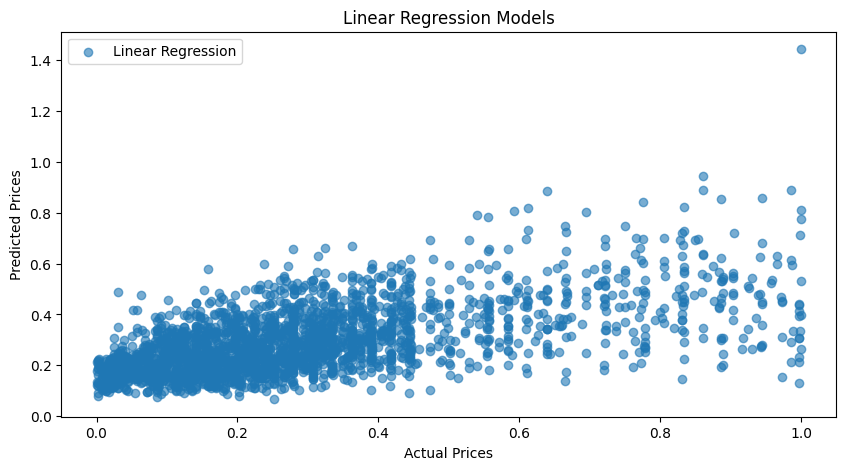

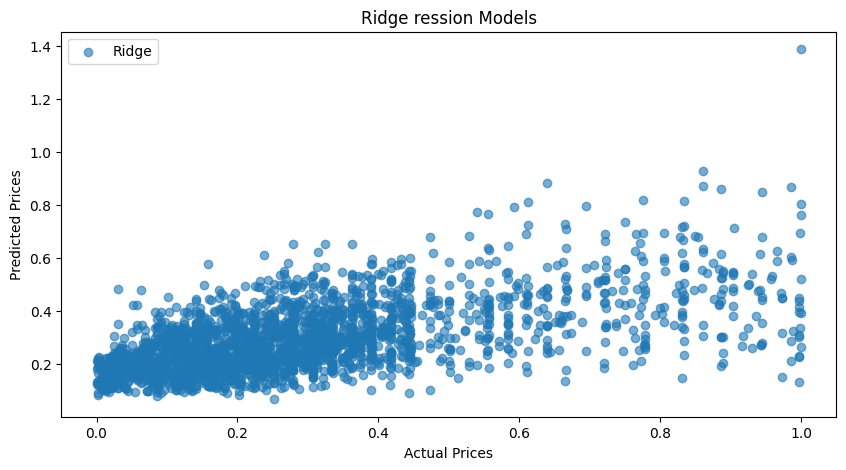

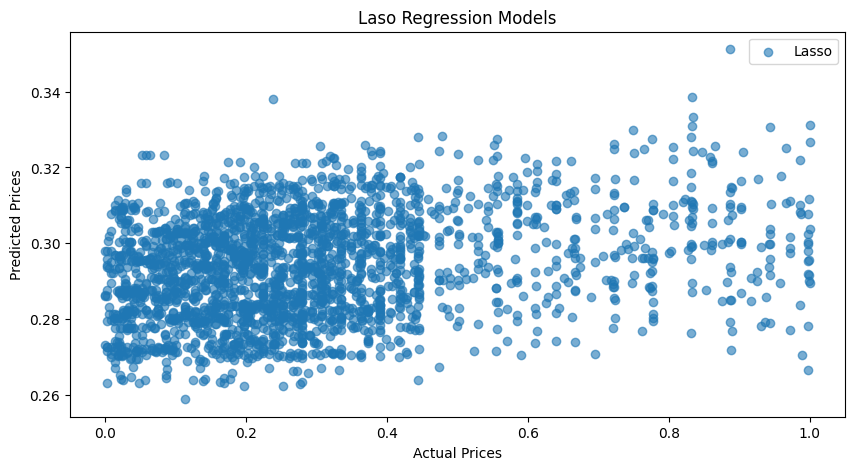

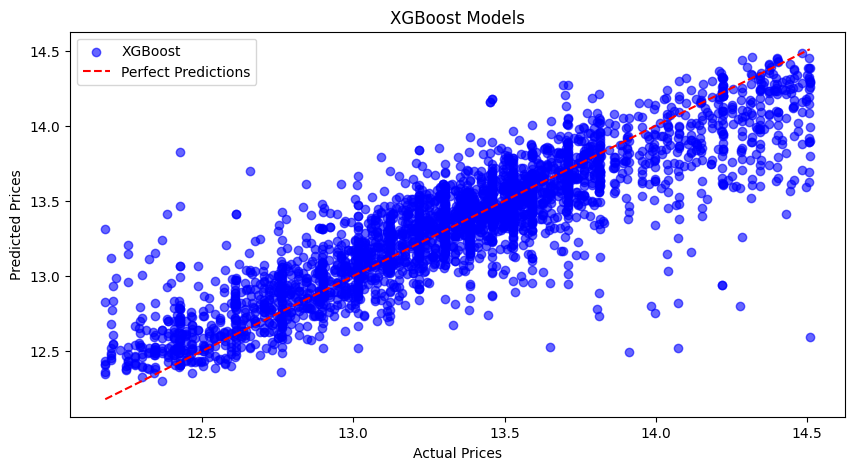

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
import pickle


# Load the dataset
df = pd.read_csv("socal2(in).csv")
df.drop(columns=['image_id'], inplace=True)

#----------------------- data preproccesing for XGBoost model--------------------------------------------------------------------------------------
df2 = pd.read_csv("socal2(in).csv")
df2.drop(columns=['image_id'], inplace=True)

df2[['street_number', 'street_name']] = df2['street'].str.extract(r'(\d+)\s(.+)') # seperate street number and street name form street
df2.drop(columns=['street'], inplace=True)

top_streets = df2["street_name"].value_counts().index[:10]  # Keep only top 10 most common streets
df2["street_name"] = df2["street_name"].apply(lambda x: x if x in top_streets else "Other") # Group rare street names

df2["price"] = np.log1p(df2["price"])
X2 = df2.drop(columns=["price"])  # Features
y2 = df2["price"]  # Target variable

categorical_features = ["citi", "street_name"] # convert categorical columns into numerical values because XGBoost only works with numeric data
noncategorical_features = ["n_citi", "bed", "bath", "sqft"] 
target_enc = TargetEncoder() # target encoding
df2[categorical_features] = target_enc.fit_transform(df2[categorical_features], df2["price"])
X2 = df2[noncategorical_features + categorical_features]  # Features (numeric + encoded categorical)
y2 = df2["price"]  # Target variable

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
#----------------------- data preproccesing for XGBoost model--------------------------------------------------------------------------------------



# Merge city and street into location
df['location'] = df['citi'] + ' ' + df['street']
df.drop_duplicates(subset="location", keep="last", inplace=True)

# Encode location with LabelEncoder
le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location'])

# Save encoding mapping
location_mapping = dict(zip(df['location_encoded'], df['location']))
with open("location_mapping.pkl", "wb") as f:
    pickle.dump(location_mapping, f)

# Normalize sqft and pricing
scaler_sqft = MinMaxScaler()
df['norm_sqft'] = scaler_sqft.fit_transform(df[['sqft']])

scaler_price = MinMaxScaler()
df['norm_price'] = scaler_price.fit_transform(df[['price']])


# Prepare training and testing data
X = df[['location_encoded', 'bed', 'bath', 'norm_sqft']]
y = df['norm_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Multiple Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

#Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

#Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=700,       # More trees for better learning
    learning_rate=0.05,     # Lower learning rate for stable training
    max_depth=7,            # Prevents excessive depth (overfitting)
    subsample=0.8,          # Uses 80% of data per tree (reduces variance)
    colsample_bytree=0.8,   # Uses 80% of features per tree (improves generalization)
    reg_lambda=1,           # L2 regularization (reduces overfitting)
    reg_alpha=0.1,          # L1 regularization (adds sparsity)
    gamma=0.1,              # Minimum loss reduction required for a split
    random_state=42
)
xgb_model.fit(X_train2, y_train2)
y_pred_xgb = xgb_model.predict(X_test2)


# SModel Evaluation Function
def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"\nModel: {model_name}")
    print(f"Mean Absolute Error      : {mae:.2f}") 
    print(f"Mean Square Error        : {mse:.2f}")
    print(f"Root Mean Absolute Error : {rmse:.2f}")
    print(f"R-squared Score          : {r2:.4f}")
    return r2

# Step 8: Compare All Models
models = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Randomforest Regression": y_pred_rf,
}

model_XG = {
    "XGBoost": y_pred_xgb,
}

best_model = None
best_r2 = -1

for model_name, y_pred in models.items():
    r2 = evaluate_model(y_test, y_pred, model_name)
    if r2 > best_r2:
        best_r2 = r2
        best_model = model_name

#------------------------- compare XGBoost seperately------------------------
r2_XG = evaluate_model(y_test2, y_pred_xgb, "XGBoost")
if r2_XG > best_r2:
    best_r2 = r2
    best_model = "XGBoost"
#------------------------- compare XGBoost seperately------------------------

#print(f"\nBest Model: {best_model} with R² Score: {best_r2:.4f}")

# Step 9: Plot Model Predictions
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_linear, label="Linear Regression", alpha=0.6)
#plt.scatter(y_test, y_pred_ridge, label="Ridge", alpha=0.6)
#plt.scatter(y_test, y_pred_lasso, label="Lasso", alpha=0.6)
#plt.scatter(y_test, y_pred_rf, label="RanForest", alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.title("Linear Regression Models")
plt.show()

# Step 9: Plot Model Predictions
plt.figure(figsize=(10, 5))
#plt.scatter(y_test, y_pred_linear, label="Linear Regression", alpha=0.6)
plt.scatter(y_test, y_pred_ridge, label="Ridge", alpha=0.6)
#plt.scatter(y_test, y_pred_lasso, label="Lasso", alpha=0.6)
#plt.scatter(y_test, y_pred_rf, label="RanForest", alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.title("Ridge ression Models")
plt.show()

# Step 9: Plot Model Predictions
plt.figure(figsize=(10, 5))
#plt.scatter(y_test, y_pred_linear, label="Linear Regression", alpha=0.6)
#plt.scatter(y_test, y_pred_ridge, label="Ridge", alpha=0.6)
plt.scatter(y_test, y_pred_lasso, label="Lasso", alpha=0.6)
#plt.scatter(y_test, y_pred_rf, label="RanForest", alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.title("Laso Regression Models")
plt.show()

# Step 9: Plot Model Predictions
plt.figure(figsize=(10, 5))
#plt.scatter(y_test, y_pred_linear, label="Linear Regression", alpha=0.6)
#plt.scatter(y_test, y_pred_ridge, label="Ridge", alpha=0.6)
#plt.scatter(y_test, y_pred_lasso, label="Lasso", alpha=0.6)
#plt.scatter(y_test, y_pred_rf, label="RanForest", alpha=0.6)
plt.scatter(y_test2, y_pred_xgb, alpha=0.6, color="blue", label="XGBoost")

# Add diagnoal line tot help visualize perfect prediction
x = np.linspace(min(y_test2), max(y_test2), 100)
plt.plot(x, x, color="red", linestyle="dashed", label="Perfect Predictions")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.title("XGBoost Models")
plt.show()

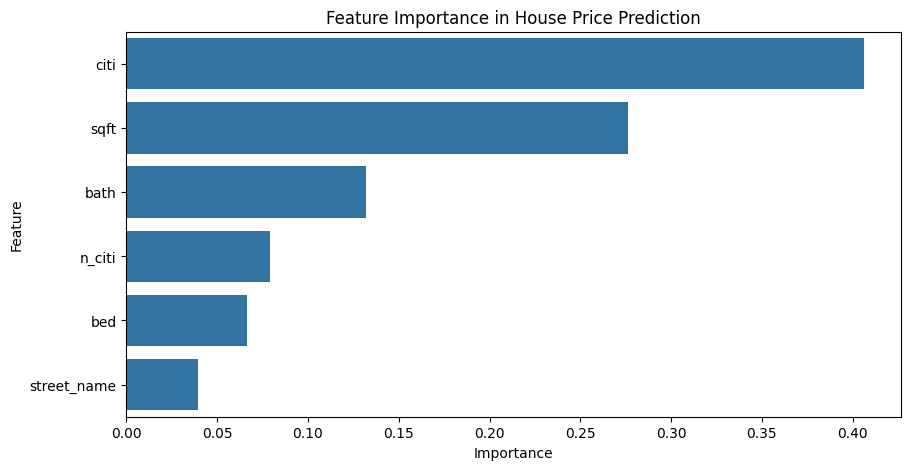

In [4]:
# Understand Which Factors Affect Prices Most

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we use the processed feature names from X_train
importance_df = pd.DataFrame({
    'Feature': X_train2.columns,  # Use X_train.columns instead of X.columns
    'Importance': xgb_model.feature_importances_
})

# Sort by importance score
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10,5))
sns.barplot(x=importance_df["Importance"], y=importance_df["Feature"])
plt.title("Feature Importance in House Price Prediction")
plt.show()

